#Phase 1: Environment Setup and Library Imports

In [1]:
import pandas as pd
import numpy as np

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set()

#Phase 2: Data Acquisition and Initial Inspection

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel("TOURIST ARRIVALS DATA.xlsx", header=0)
df.head()

Saving TOURIST ARRIVALS DATA.xlsx to TOURIST ARRIVALS DATA.xlsx


,DATE,MONTH,TOURIST ARRIVALS,HOLIDAY,BUSINESS,VFR,OTHERS
0,2019-01,JANUARY,168541.0,106434.0,22753.0,17865.0,21489.0
1,2019-02,FEBRUARY,150872.0,95276.0,20368.0,15992.0,19236.0
2,2019-03,MARCH,163210.0,103067.0,22033.0,17300.0,20810.0
3,2019-04,APRIL,148950.0,94062.0,20108.0,15789.0,18991.0
4,2019-05,MAY,134355.0,84845.0,18138.0,14242.0,17130.0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Phase 3: Data Preprocessing and Outlier Management

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['date', 'month', 'tourist_arrivals', 'holiday', 'business', 'vfr',
       'others'],
      dtype='object')

In [5]:
# Convert Date column to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m')

# Sort data
df = df.sort_index()

# Set Date as index
df.set_index('date', inplace=True)

df = df.asfreq('MS')

# Preview
print(df.index)
print(df.head())


DatetimeIndex(['2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01',
               '2019-05-01', '2019-06-01', '2019-07-01', '2019-08-01',
               '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01',
               '2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01',
               '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01',
               '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01',
               '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01',
               '2021-05-01', '2021-06-01', '2021-07-01', '2021-08-01',
               '2021-09-01', '2021-10-01', '2021-11-01', '2021-12-01',
               '2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
               '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01',
               '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
      

In [6]:
# Check info
df.info()

# Check missing values
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 84 entries, 2019-01-01 to 2025-12-01
Freq: MS
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             84 non-null     object 
 1   tourist_arrivals  84 non-null     float64
 2   holiday           84 non-null     float64
 3   business          84 non-null     float64
 4   vfr               84 non-null     float64
 5   others            84 non-null     float64
dtypes: float64(5), object(1)
memory usage: 4.6+ KB


np.int64(0)

In [7]:
#handling missing values
df['tourist_arrivals']=df['tourist_arrivals'].interpolate(method='linear')

In [8]:
#drop duplicate rows
df = df[~df.index.duplicated(keep='first')]

In [9]:
# Create full monthly date range
full_range = pd.date_range(start='2019-01-01', end='2025-12-01', freq='MS')

# Reindex dataset
df = df.reindex(full_range)

# Rename index
df.index.name = 'date'

# Fill missing months
df['tourist_arrivals'] = df['tourist_arrivals'].interpolate()

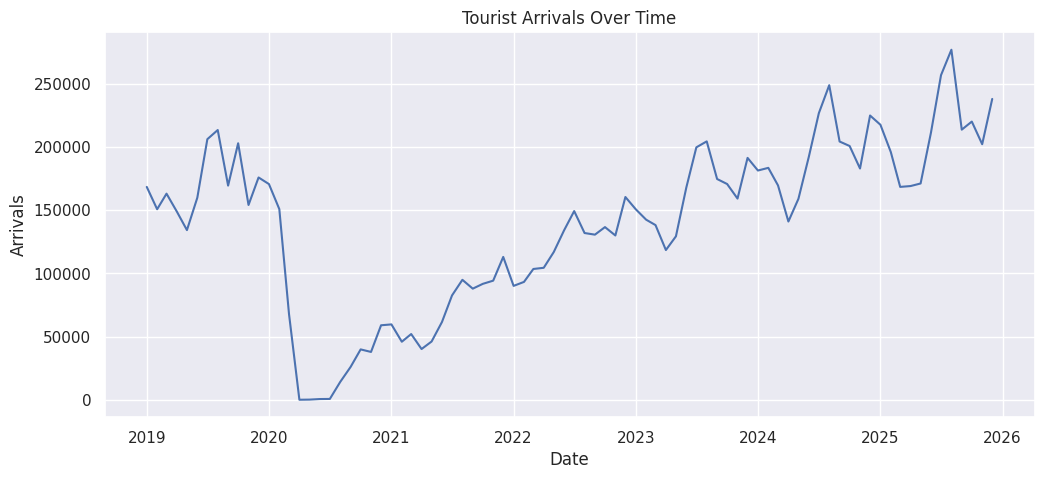

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['tourist_arrivals'])
plt.title("Tourist Arrivals Over Time")
plt.xlabel("Date")
plt.ylabel("Arrivals")
plt.show()

In [11]:
from scipy.stats import zscore

# Calculate Z-scores
df['Z_score'] = zscore(df['tourist_arrivals'])

# Identify outliers (threshold = 3)
outliers_z = df[np.abs(df['Z_score']) > 3]

print(outliers_z)

Empty DataFrame
Columns: [month, tourist_arrivals, holiday, business, vfr, others, Z_score]
Index: []


In [12]:
Q1 = df['tourist_arrivals'].quantile(0.25)
Q3 = df['tourist_arrivals'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['tourist_arrivals'] < lower_bound) | (df['tourist_arrivals'] > upper_bound)]

print(outliers_iqr)

Empty DataFrame
Columns: [month, tourist_arrivals, holiday, business, vfr, others, Z_score]
Index: []


In [13]:
# Create COVID dummy variable
df['COVID_Shock'] = 0

# Mark COVID period (April 2020 – July 2020)
df.loc['2020-04-01':'2020-07-01', 'COVID_Shock'] = 1

In [14]:
df['tourist_arrivals_capped'] = np.where(df['tourist_arrivals'] > upper_bound, upper_bound,
                         np.where(df['tourist_arrivals'] < lower_bound, lower_bound,
                                  df['tourist_arrivals']))

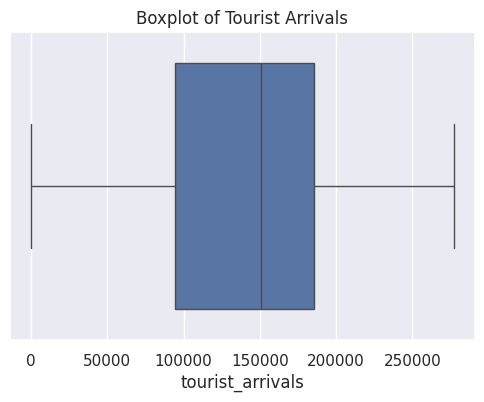

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['tourist_arrivals'])
plt.title("Boxplot of Tourist Arrivals")
plt.show()

In [16]:
df.describe()

,tourist_arrivals,holiday,business,vfr,others,Z_score,COVID_Shock,tourist_arrivals_capped
count,84.000000,84.000000,84.000000,84.000000,84.000000,8.400000e+01,84.000000,84.000000
mean,140228.500000,64181.189384,32542.199337,31533.024424,11838.619048,6.344132e-17,0.047619,140228.500000
std,65983.529844,38276.792686,16382.085090,15748.775828,5967.789080,1.006006e+00,0.214238,65983.529844
min,27.000000,7.000000,5.000000,12.000000,3.000000,-2.137557e+00,0.000000,27.000000
25%,94070.500000,33627.742330,21281.447434,17947.500000,8395.750000,-7.037397e-01,0.000000,94070.500000
50%,150920.000000,65807.000000,31002.669725,31890.500000,11407.000000,1.630060e-01,0.000000,150920.000000
75%,185616.500000,96896.500000,44036.250000,41755.575947,14603.250000,6.920000e-01,0.000000,185616.500000
max,277155.000000,134883.000000,69871.000000,75495.000000,27232.000000,2.087625e+00,1.000000,277155.000000


#Phase 4: Exploratory Data Analysis (EDA) and Seasonal Decomposition

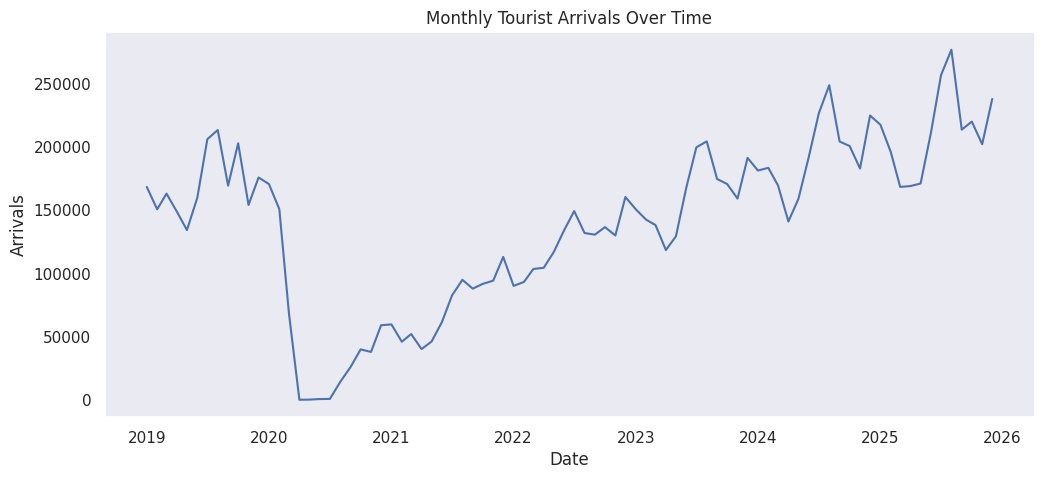

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index, df['tourist_arrivals'])
plt.title("Monthly Tourist Arrivals Over Time")
plt.xlabel("Date")
plt.ylabel("Arrivals")
plt.grid()
plt.show()

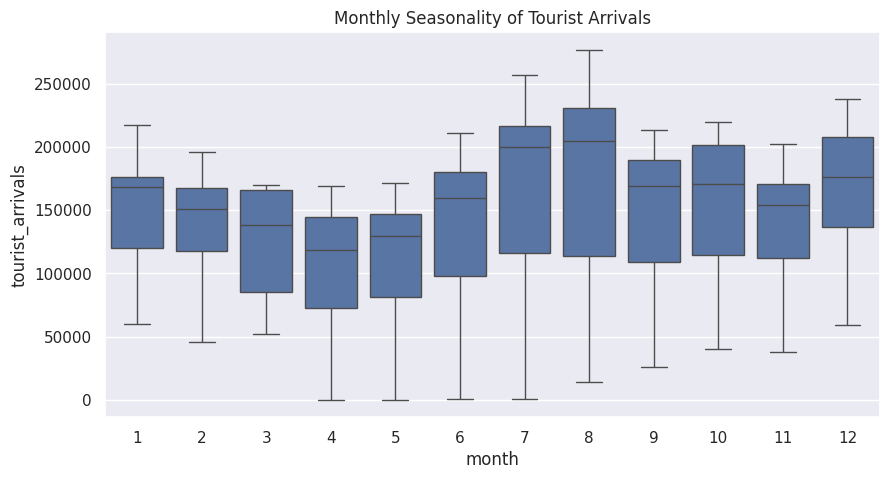

In [18]:
import seaborn as sns

df['month'] = df.index.month

plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='tourist_arrivals', data=df)
plt.title("Monthly Seasonality of Tourist Arrivals")
plt.show()

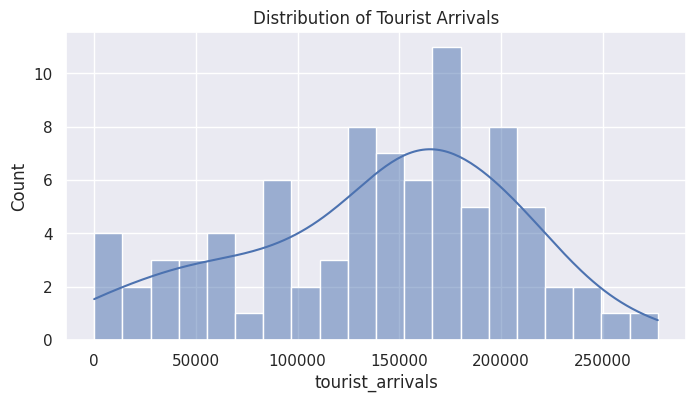

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df['tourist_arrivals'], bins=20, kde=True)
plt.title("Distribution of Tourist Arrivals")
plt.show()

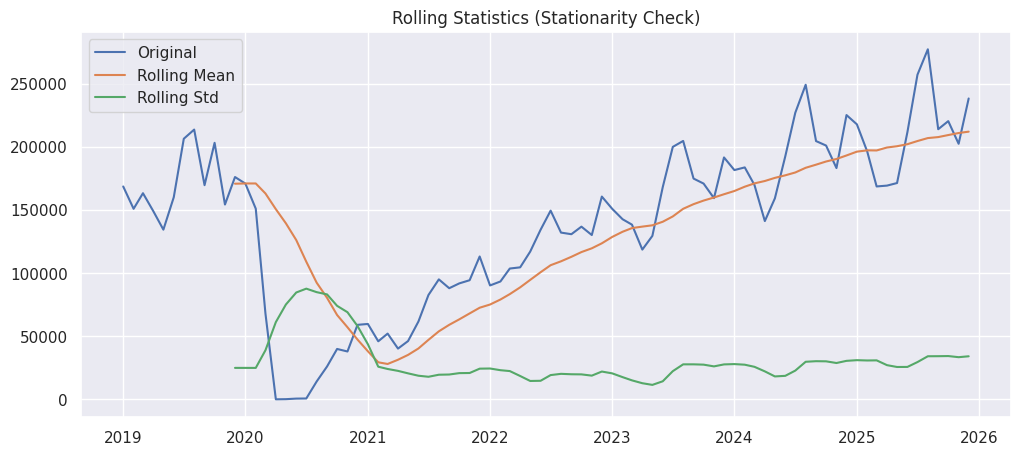

In [20]:
rolling_mean = df['tourist_arrivals'].rolling(window=12).mean()
rolling_std = df['tourist_arrivals'].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df['tourist_arrivals'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title("Rolling Statistics (Stationarity Check)")
plt.show()

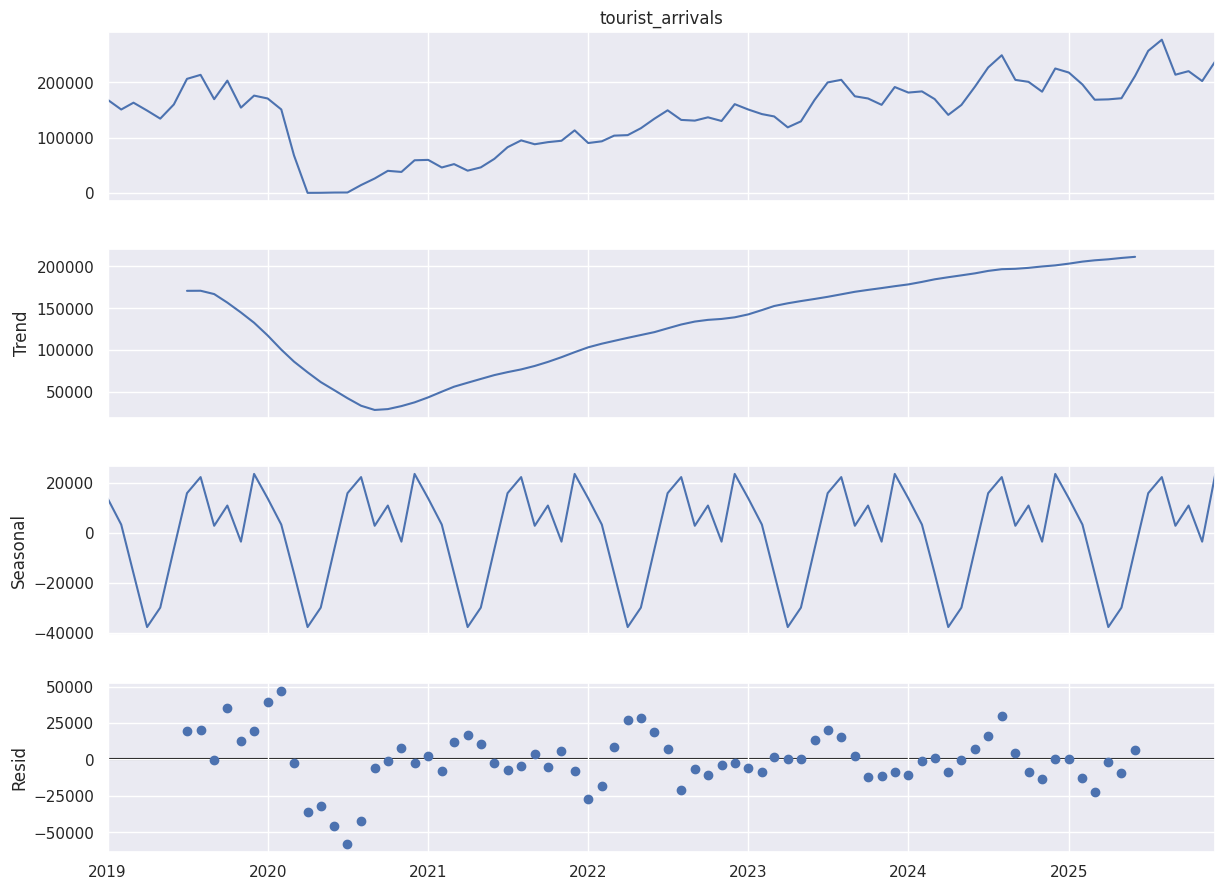

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import os

# Create folder if it doesn't exist
os.makedirs('charts', exist_ok=True)

# Perform decomposition
decomposition = seasonal_decompose(
    df['tourist_arrivals'],
    model='additive',
    period=12
)

# Plot decomposition
fig = decomposition.plot()
fig.set_size_inches(14, 10)

# Save figure
plt.savefig(
    'charts/Seasonal_Decomposition.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

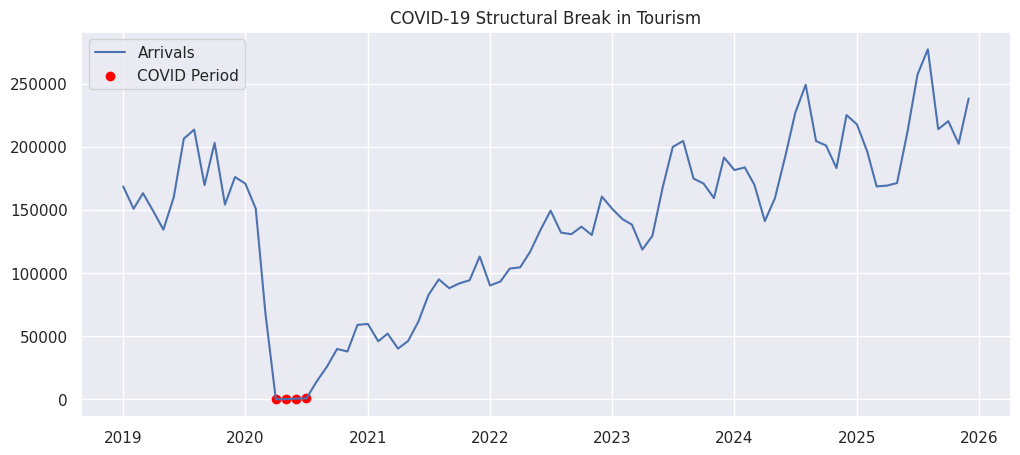

In [22]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['tourist_arrivals'], label='Arrivals')

plt.scatter(df.index[df['COVID_Shock']==1],
            df['tourist_arrivals'][df['COVID_Shock']==1],
            color='red', label='COVID Period')

plt.legend()
plt.title("COVID-19 Structural Break in Tourism")
plt.show()

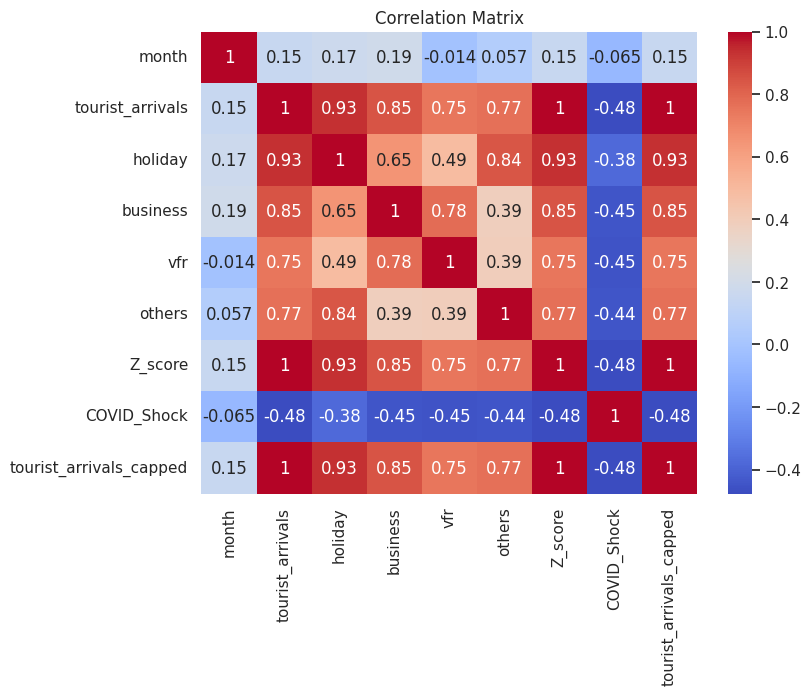

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#Phase 5: Model Identification and Stationarity Testing

In [24]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['tourist_arrivals'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary ✅")
else:
    print("Series is Non-Stationary ❌ (Differencing required)")

ADF Statistic: -1.5053162831043916
p-value: 0.5308798295115102
Series is Non-Stationary ❌ (Differencing required)


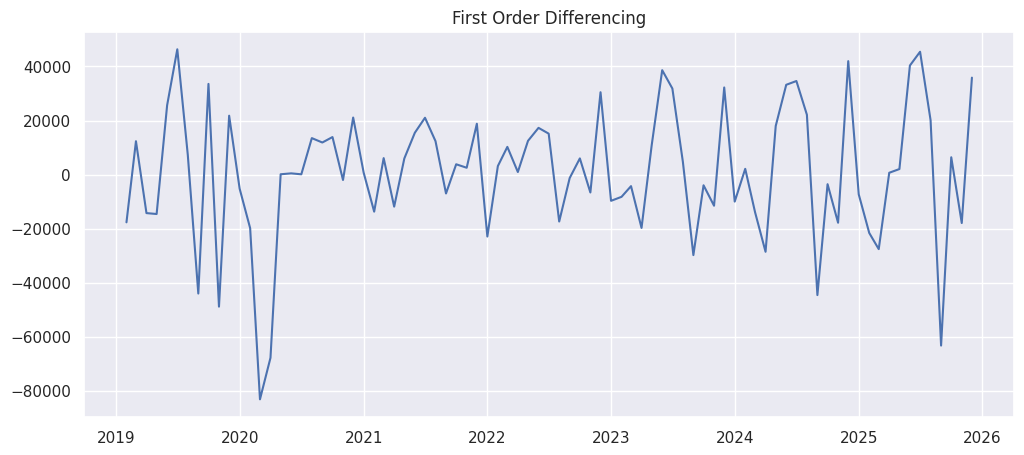

In [25]:
df['diff_1'] = df['tourist_arrivals'].diff()

plt.figure(figsize=(12,5))
plt.plot(df['diff_1'])
plt.title("First Order Differencing")
plt.show()

In [26]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['diff_1'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Now Stationary ✅")
else:
    print("Still Non-Stationary ❌")

ADF Statistic: -1.8269364408163595
p-value: 0.3671728589029495
Still Non-Stationary ❌


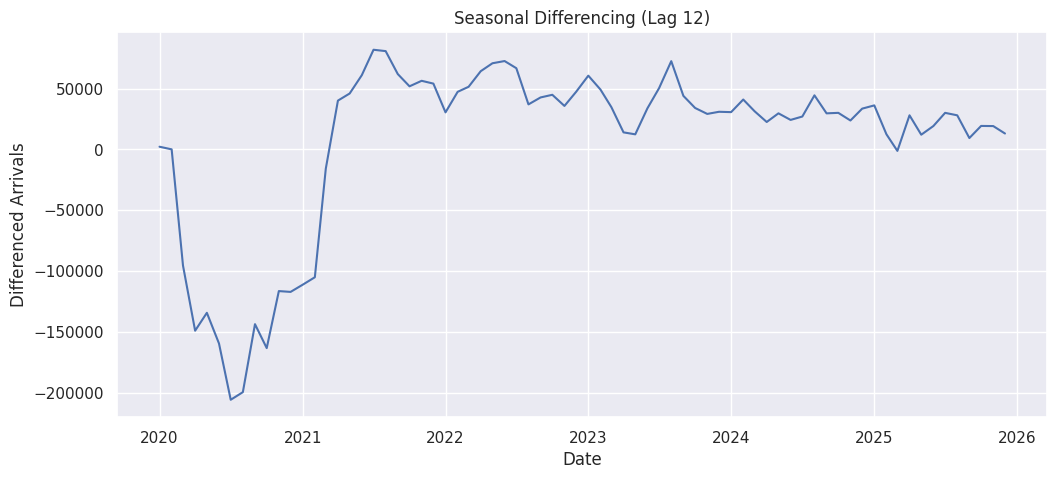

In [27]:
# Seasonal differencing (12 months)
df['seasonal_diff'] = df['tourist_arrivals'].diff(12)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['seasonal_diff'])
plt.title('Seasonal Differencing (Lag 12)')
plt.xlabel('Date')
plt.ylabel('Differenced Arrivals')
plt.grid(True)
plt.show()

In [28]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['seasonal_diff'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print('Series is Stationary ✅')
else:
    print('Still Non-Stationary ❌')

ADF Statistic: -5.284326144108026
p-value: 5.900199304282669e-06
Series is Stationary ✅


<Figure size 1400x600 with 0 Axes>

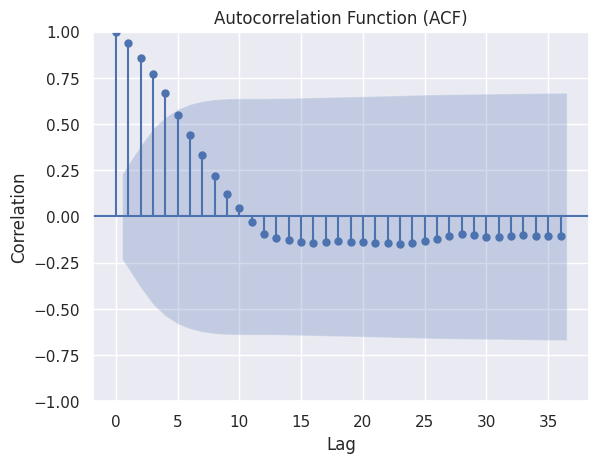

<Figure size 1400x600 with 0 Axes>

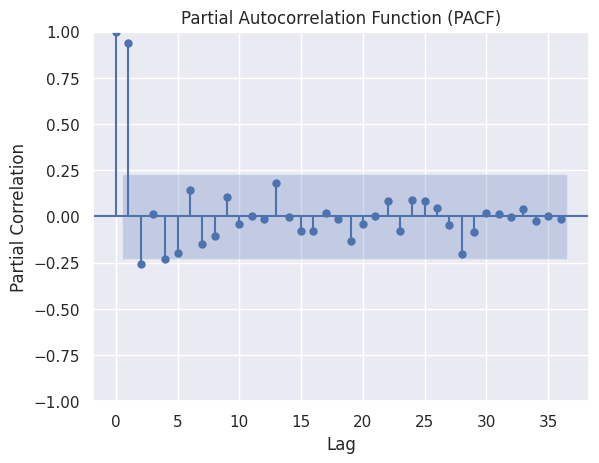

ACF and PACF plots saved successfully in the 'charts' folder.


In [29]:
# Import required libraries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import os

# Create folder for charts
os.makedirs('charts', exist_ok=True)

# Remove missing values
seasonal_series = df['seasonal_diff'].dropna()

# -------------------------------------------------
# Autocorrelation Function (ACF)
# -------------------------------------------------
plt.figure(figsize=(14, 6))
plot_acf(seasonal_series, lags=36)

plt.title('Autocorrelation Function (ACF)')
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.grid(True)

plt.savefig(
    'charts/ACF_Plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

# -------------------------------------------------
# Partial Autocorrelation Function (PACF)
# -------------------------------------------------
plt.figure(figsize=(14, 6))
plot_pacf(
    seasonal_series,
    lags=36,
    method='ywm'
)

plt.title('Partial Autocorrelation Function (PACF)')
plt.xlabel('Lag')
plt.ylabel('Partial Correlation')
plt.grid(True)

plt.savefig(
    'charts/PACF_Plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("ACF and PACF plots saved successfully in the 'charts' folder.")

#Phase 6: Model Implementation and Comparative Evaluation

Training observations: 72
Testing observations: 12

ARIMA Performance
----------------------------------------
MAE  : 30,218.54
RMSE : 35,903.41
MAPE : 15.34%

SARIMA Performance
----------------------------------------
MAE  : 11,762.24
RMSE : 14,619.38
MAPE : 5.57%

Holt-Winters Performance
----------------------------------------
MAE  : 15,385.76
RMSE : 19,615.83
MAPE : 7.06%

Prophet Performance
----------------------------------------
MAE  : 35,028.12
RMSE : 38,509.58
MAPE : 16.30%

MODEL COMPARISON
          Model           MAE          RMSE       MAPE
1        SARIMA  11762.241762  14619.380687   5.569687
2  Holt-Winters  15385.764990  19615.829006   7.056659
0         ARIMA  30218.538429  35903.411899  15.339555
3       Prophet  35028.118927  38509.579944  16.300079


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


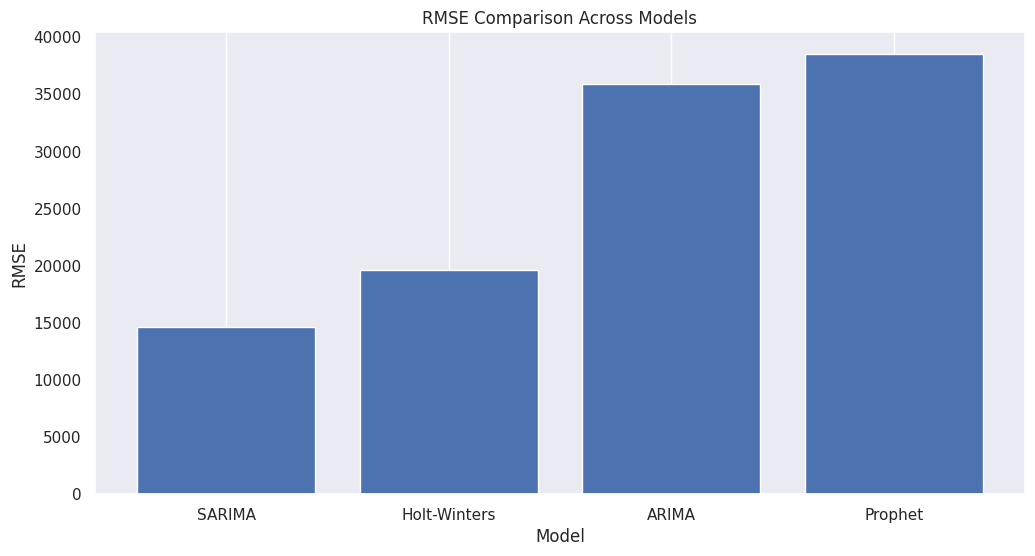


Best Performing Model: SARIMA

Results saved successfully.


In [30]:
# ============================================================
# TIME SERIES MODEL COMPARISON FOR TOURIST ARRIVALS
# Models:
# 1. ARIMA
# 2. SARIMA
# 3. Holt-Winters Exponential Smoothing
# 4. Prophet
# 5. ARIMAX (Optional - requires external variables)
# ============================================================

# Install Prophet (Run only once in Google Colab)
# !pip install prophet

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from prophet import Prophet

# ============================================================
# SPLIT DATA INTO TRAINING AND TEST SETS
# Last 12 months reserved for testing
# ============================================================

train = df.iloc[:-12]
test = df.iloc[-12:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

# ============================================================
# FUNCTION TO EVALUATE FORECAST ACCURACY
# ============================================================

def evaluate_model(actual, predicted, model_name):
    """
    Calculate forecasting performance metrics.
    """
    mae = mean_absolute_error(actual, predicted)
    rmse = sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    print(f"\n{model_name} Performance")
    print("-" * 40)
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAPE : {mape:.2f}%")

    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# ============================================================
# 1. ARIMA MODEL
# ============================================================

# Fit ARIMA model
arima_model = ARIMA(train['tourist_arrivals'], order=(1,1,1))
arima_fit = arima_model.fit()

# Forecast next 12 months
arima_forecast = arima_fit.forecast(steps=12)

# Evaluate
arima_results = evaluate_model(
    test['tourist_arrivals'],
    arima_forecast,
    "ARIMA"
)

# ============================================================
# 2. SARIMA MODEL
# ============================================================

sarima_model = SARIMAX(
    train['tourist_arrivals'],
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

sarima_forecast = sarima_fit.forecast(steps=12)

sarima_results = evaluate_model(
    test['tourist_arrivals'],
    sarima_forecast,
    "SARIMA"
)

# ============================================================
# 3. HOLT-WINTERS EXPONENTIAL SMOOTHING
# ============================================================

hw_model = ExponentialSmoothing(
    train['tourist_arrivals'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

hw_fit = hw_model.fit()

hw_forecast = hw_fit.forecast(12)

hw_results = evaluate_model(
    test['tourist_arrivals'],
    hw_forecast,
    "Holt-Winters"
)

# ============================================================
# 4. PROPHET MODEL
# ============================================================

# Prepare data for Prophet
prophet_train = train.reset_index()[['date', 'tourist_arrivals']]
prophet_train.columns = ['ds', 'y']

# Initialize and fit Prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

# Create future dates
future = prophet_model.make_future_dataframe(periods=12, freq='M')

# Forecast
prophet_forecast = prophet_model.predict(future)

# Extract forecasted values
prophet_predictions = prophet_forecast['yhat'].tail(12).values

prophet_results = evaluate_model(
    test['tourist_arrivals'].values,
    prophet_predictions,
    "Prophet"
)

# ============================================================
# COMPILE RESULTS
# ============================================================

results_df = pd.DataFrame([
    arima_results,
    sarima_results,
    hw_results,
    prophet_results
])

# Sort by RMSE
results_df = results_df.sort_values('RMSE')

print("\nMODEL COMPARISON")
print("=" * 60)
print(results_df)

# ============================================================
# VISUALIZE MODEL PERFORMANCE
# ============================================================

plt.figure(figsize=(12, 6))
plt.bar(results_df['Model'], results_df['RMSE'])
plt.title('RMSE Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.grid(axis='y')
plt.show()

# ============================================================
# IDENTIFY BEST MODEL
# ============================================================

best_model = results_df.iloc[0]['Model']

print(f"\nBest Performing Model: {best_model}")

# ============================================================
# OPTIONAL: SAVE RESULTS
# ============================================================

results_df.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved successfully.")

#Phase 7: Final Model Selection and Future Projections (2026–2027)

                                     SARIMAX Results                                      
Dep. Variable:                   tourist_arrivals   No. Observations:                   84
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -645.051
Date:                            Wed, 17 Jun 2026   AIC                           1300.103
Time:                                    04:21:34   BIC                           1310.405
Sample:                                01-01-2019   HQIC                          1304.116
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8696      0.112      7.771      0.000       0.650       1.089
ma.L1          0.3590      0.221   

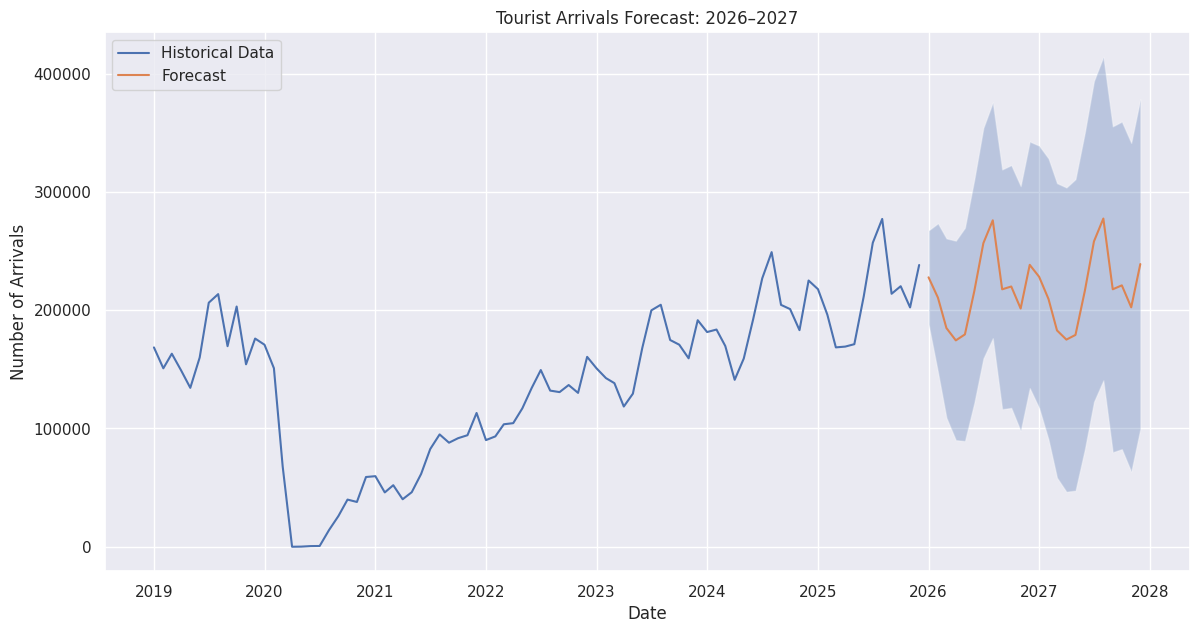

  adding: sarima_forecast/ (stored 0%)
  adding: sarima_forecast/forecast_plot.png (deflated 11%)
  adding: sarima_forecast/tourist_arrivals_forecast_2026_2027.csv (deflated 50%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Forecast + chart saved successfully.


In [31]:
# Import required libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import matplotlib.pyplot as plt
import os
from google.colab import files

# ------------------------------------------------------------
# Create folder for outputs
# ------------------------------------------------------------
os.makedirs('sarima_forecast', exist_ok=True)

# ------------------------------------------------------------
# Fit SARIMA model using full dataset
# ------------------------------------------------------------
final_model = SARIMAX(
    df['tourist_arrivals'],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit()

print(final_results.summary())

# ------------------------------------------------------------
# Forecast next 24 months
# ------------------------------------------------------------
forecast_steps = 24
forecast = final_results.get_forecast(steps=forecast_steps)

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# ------------------------------------------------------------
# Future dates
# ------------------------------------------------------------
future_dates = pd.date_range(
    start=df.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq='MS'
)

forecast_df = pd.DataFrame({
    'Forecast': forecast_mean.values,
    'Lower_CI': forecast_ci.iloc[:, 0].values,
    'Upper_CI': forecast_ci.iloc[:, 1].values
}, index=future_dates)

print(forecast_df)

# ------------------------------------------------------------
# Plot forecast
# ------------------------------------------------------------
plt.figure(figsize=(14, 7))

plt.plot(df.index, df['tourist_arrivals'], label='Historical Data')
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast')

plt.fill_between(
    forecast_df.index,
    forecast_df['Lower_CI'],
    forecast_df['Upper_CI'],
    alpha=0.3
)

plt.title('Tourist Arrivals Forecast: 2026–2027')
plt.xlabel('Date')
plt.ylabel('Number of Arrivals')
plt.legend()
plt.grid(True)

# ✅ SAVE FIGURE
plt.savefig(
    'sarima_forecast/forecast_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------
forecast_df.to_csv('sarima_forecast/tourist_arrivals_forecast_2026_2027.csv')

# ------------------------------------------------------------
# Zip and download everything
# ------------------------------------------------------------
!zip -r sarima_forecast.zip sarima_forecast
files.download('sarima_forecast.zip')

print("Forecast + chart saved successfully.")

#Phase 8: Model Validation and Residual Diagnostics

SARIMA Model Accuracy
MAE  : 11,762.24
RMSE : 14,619.38
MAPE : 5.57%


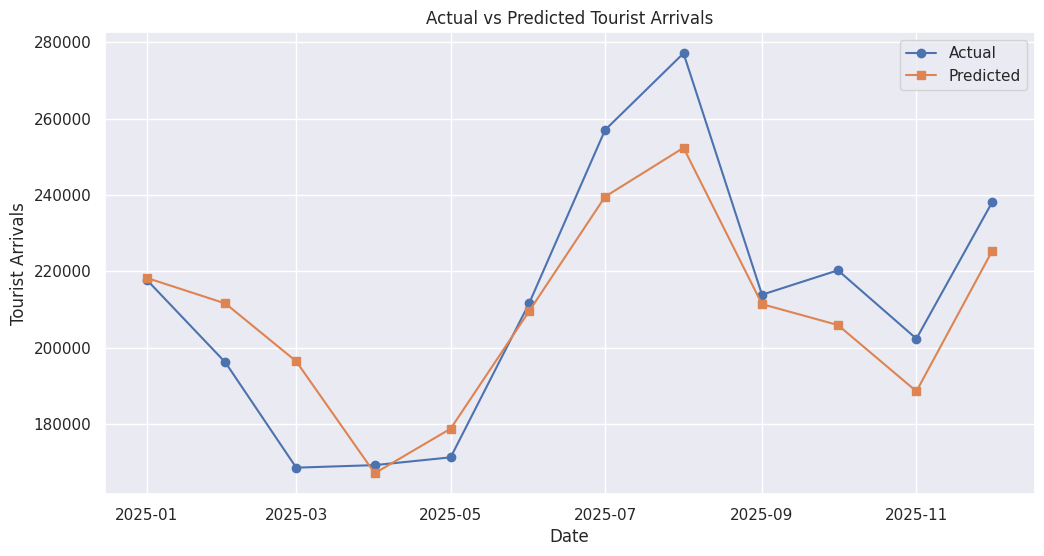

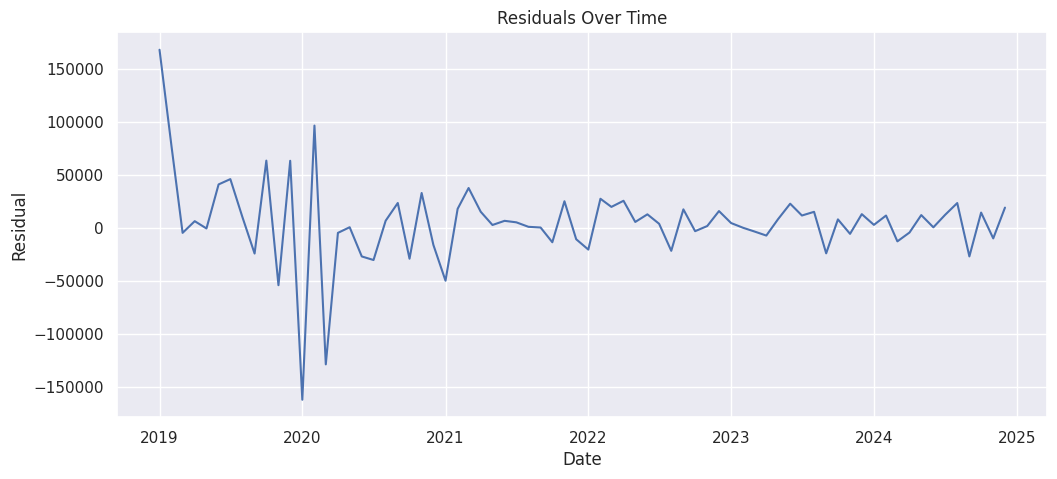

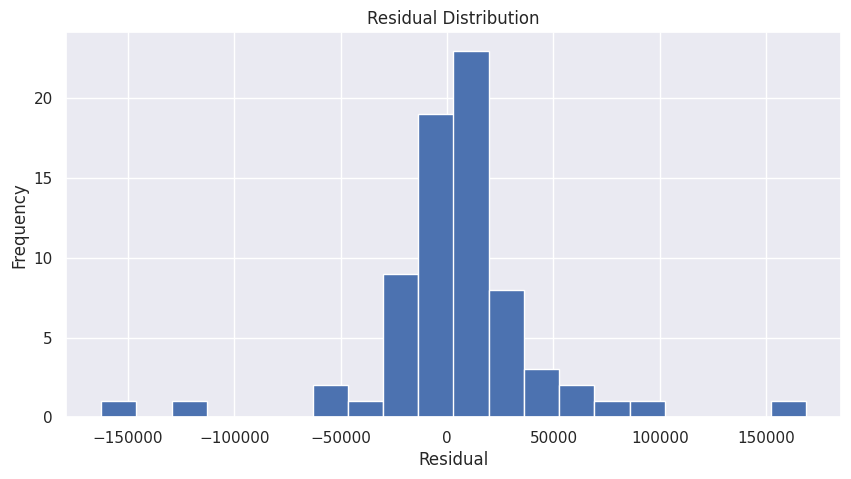


Ljung-Box Test
      lb_stat  lb_pvalue
12  22.117557   0.036223

Residuals exhibit autocorrelation ❌
  adding: sarima_charts/ (stored 0%)
  adding: sarima_charts/sarima_actual_vs_predicted.csv (deflated 50%)
  adding: sarima_charts/Actual_vs_Predicted.png (deflated 12%)
  adding: sarima_charts/Residual_Distribution.png (deflated 33%)
  adding: sarima_charts/Residuals_Over_Time.png (deflated 12%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All charts and results downloaded successfully.


In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
from statsmodels.stats.diagnostic import acorr_ljungbox
from google.colab import files

# ------------------------------------------------------------
# Create folder for charts
# ------------------------------------------------------------
os.makedirs('sarima_charts', exist_ok=True)

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------
predictions = sarima_fit.forecast(steps=len(test))

# ------------------------------------------------------------
# Accuracy Metrics
# ------------------------------------------------------------
mae = mean_absolute_error(
    test['tourist_arrivals'],
    predictions
)

rmse = sqrt(
    mean_squared_error(
        test['tourist_arrivals'],
        predictions
    )
)

mape = np.mean(
    np.abs(
        (test['tourist_arrivals'] - predictions)
        / test['tourist_arrivals']
    )
) * 100

# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------
print("SARIMA Model Accuracy")
print("=" * 40)
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

# ------------------------------------------------------------
# Actual vs Predicted Plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    test.index,
    test['tourist_arrivals'],
    marker='o',
    label='Actual'
)

plt.plot(
    test.index,
    predictions,
    marker='s',
    label='Predicted'
)

plt.title('Actual vs Predicted Tourist Arrivals')
plt.xlabel('Date')
plt.ylabel('Tourist Arrivals')
plt.legend()
plt.grid(True)

plt.savefig(
    'sarima_charts/Actual_vs_Predicted.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

# ------------------------------------------------------------
# Residual Time Series Plot
# ------------------------------------------------------------
residuals = sarima_fit.resid

plt.figure(figsize=(12, 5))
plt.plot(residuals)

plt.title('Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)

plt.savefig(
    'sarima_charts/Residuals_Over_Time.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

# ------------------------------------------------------------
# Residual Distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=20)

plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.grid(True)

plt.savefig(
    'sarima_charts/Residual_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

# ------------------------------------------------------------
# Ljung-Box Test
# ------------------------------------------------------------
ljung_box = acorr_ljungbox(
    residuals,
    lags=[12],
    return_df=True
)

print("\nLjung-Box Test")
print("=" * 40)
print(ljung_box)

if ljung_box['lb_pvalue'].iloc[0] > 0.05:
    print("\nResiduals are white noise ✅")
else:
    print("\nResiduals exhibit autocorrelation ❌")

# ------------------------------------------------------------
# Save Prediction Results
# ------------------------------------------------------------
comparison_df = pd.DataFrame({
    'Actual': test['tourist_arrivals'],
    'Predicted': predictions
})

comparison_df.to_csv(
    'sarima_charts/sarima_actual_vs_predicted.csv',
    index=True
)

!zip -r sarima_charts.zip sarima_charts

files.download('sarima_charts.zip')

print("\nAll charts and results downloaded successfully.")

In [33]:
import pickle

In [34]:
pickle.dump(arima_model, open("arima.pkl", "wb"))

In [35]:
pickle.dump(sarima_model, open("sarima.pkl", "wb"))

In [36]:
pickle.dump(hw_model, open("holtwinters.pkl", "wb"))

In [37]:
with open("prophet.pkl", "wb") as f:
    pickle.dump(prophet_model, f)

In [38]:
from google.colab import files

files.download("arima.pkl")
files.download("sarima.pkl")
files.download("holtwinters.pkl")
files.download("prophet.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 95.3 MB/s eta 0:00:00


In [40]:
import streamlit as st
import pickle
import pandas as pd
import matplotlib.pyplot as plt

st.title("Kenya Tourism Forecasting Dashboard")
st.write("Comparison of ARIMA, SARIMA, Prophet, and Holt-Winters models")

# Load models
models = {
    "ARIMA": pickle.load(open("arima.pkl", "rb")),
    "SARIMA": pickle.load(open("sarima.pkl", "rb")),
    "Prophet": pickle.load(open("prophet.pkl", "rb")),
    "Holt-Winters": pickle.load(open("holtwinters.pkl", "rb"))
}

model_name = st.selectbox("Select Model", list(models.keys()))
periods = st.slider("Forecast Horizon (Years)", 1, 10, 5)

model = models[model_name]

if st.button("Forecast"):

    if model_name == "Prophet":
        future = model.make_future_dataframe(periods=periods, freq='Y')
        forecast = model.predict(future)
        result = forecast[['ds', 'yhat']].tail(periods)
        result.columns = ["Year", "Forecast"]

    else:
        forecast = model.forecast(steps=periods)
        years = list(range(2024, 2024 + periods))
        result = pd.DataFrame({
            "Year": years,
            "Forecast": forecast
        })

    st.subheader(f"{model_name} Forecast Results")
    st.dataframe(result)

    fig, ax = plt.subplots()
    ax.plot(result["Year"], result["Forecast"], marker="o")
    ax.set_title(f"{model_name} Forecast")
    ax.set_xlabel("Year")
    ax.set_ylabel("Tourist Arrivals")

    st.pyplot(fig)

2026-06-17 04:21:46.313 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 04:21:46.471 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-17 04:21:46.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 04:21:46.472 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 04:21:46.474 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 04:21:46.475 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 04:21:46.476 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 04:21:46.484 Thread 'MainThread': mi